# Cardiovascular Disease Prediction
Training and comparison of tree-based classifiers on the [Kaggle Cardiovascular Disease dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset).

**Before running:** download `cardio_train.csv` from Kaggle and place it in this folder. Run the cells in order, because cell 1 creates the files the later cells load.

## 1. Data preparation and baseline Decision Tree
Loads `cardio_train.csv`, removes outliers with the IQR method, converts age from days to years, fits a z-score scaler, then trains and tunes a Decision Tree with `GridSearchCV`. Writes `cardio_clean.csv`, `cardio_clean_labels.csv` and `scaler.joblib` for the next cells.

Data Overview:
    id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
Missing Values:
 age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
Data Types:
 age              int64
gender           int64
height           int64
weight         float64
ap_hi   

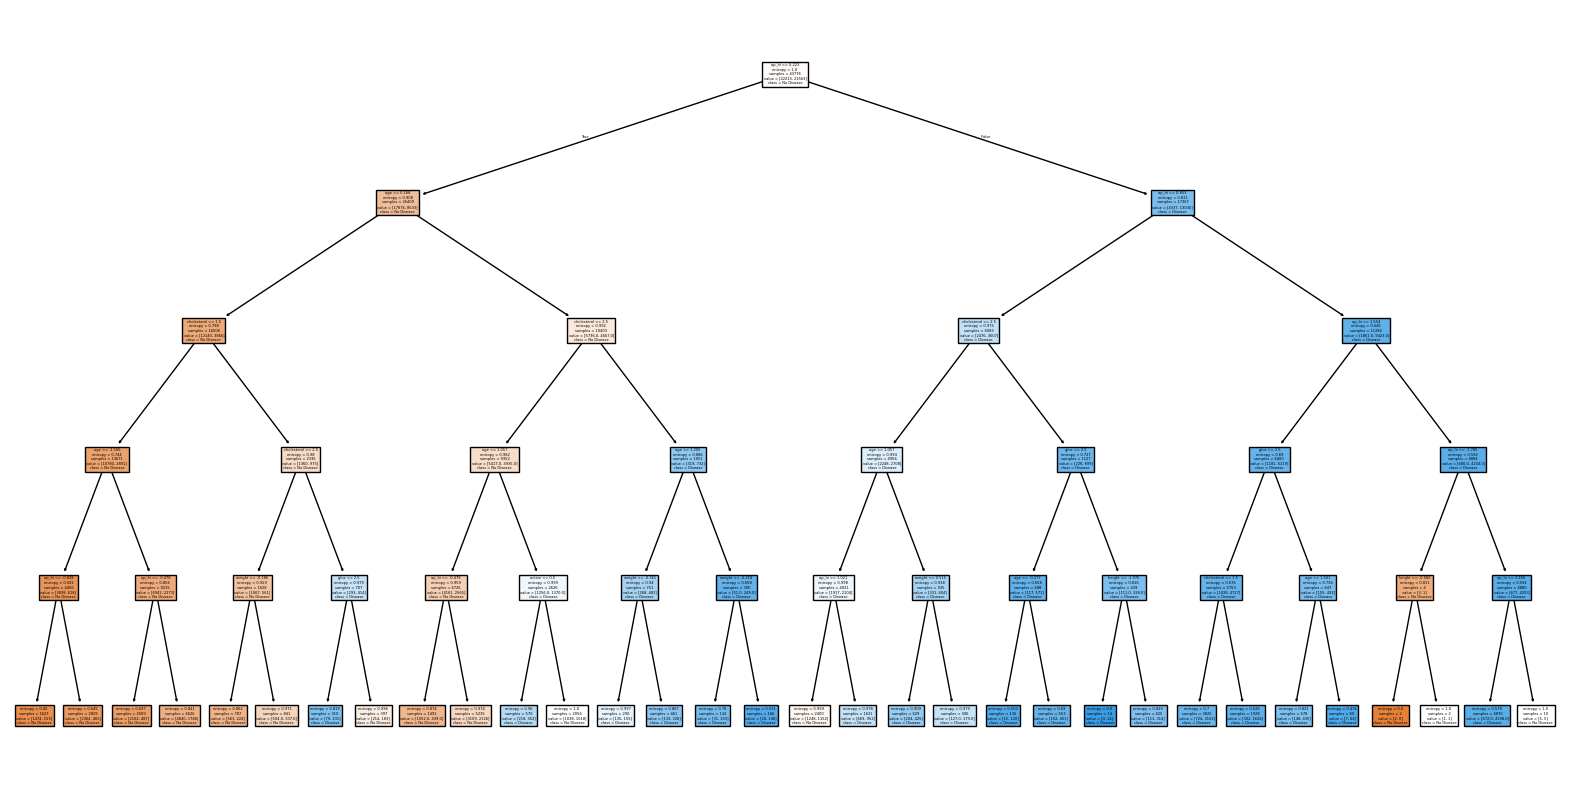

Final Test Accuracy: 0.719
Confusion Matrix:
 [[8743 1718]
 [4183 6356]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.84      0.75     10461
           1       0.79      0.60      0.68     10539

    accuracy                           0.72     21000
   macro avg       0.73      0.72      0.72     21000
weighted avg       0.73      0.72      0.72     21000



In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

# Load Dataset
df = pd.read_csv('cardio_train.csv', sep=';')

# Data Overview
print("Data Overview:\n", df.head())

# Drop Irrelevant Column (e.g., 'id')
df = df.drop(columns=['id'])

# Check Missing Values
print("Missing Values:\n", df.isnull().sum())

# Data Types
print("Data Types:\n", df.dtypes)

# Split Data into Features and Target
X = df.drop(columns=['cardio'])  # Features
y = df['cardio']                # Target

# Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define Numerical Columns
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

# Outlier Removal (IQR Method)
def remove_outliers_iqr(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

X_train = remove_outliers_iqr(X_train, numerical_columns)

# Align y_train with X_train
y_train = y_train.loc[X_train.index]

# Transform Age from Days to Years
X_train['age'] = (X_train['age'] / 365).round()
X_test['age'] = (X_test['age'] / 365).round()

# Export Cleaned Dataset
X_train.to_csv("cardio_clean.csv", index=False)
y_train.to_csv("cardio_clean_labels.csv", index=False)

# Z-Score Normalization
scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

# Save Scaler
joblib.dump(scaler, "scaler.joblib")
print("Scaler saved as scaler.joblib")

# Baseline Decision Tree Model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Evaluate Baseline Model
y_pred = clf.predict(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Hyperparameter Tuning with GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

# Final Model with Best Parameters
best_model = grid_search.best_estimator_

# Feature Importance
importances = best_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
print("Feature Importance:\n", feature_importance_df.sort_values(by='Importance', ascending=False))

# Cross-Validation
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", cv_scores.mean())

# Visualize Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=X_train.columns, class_names=['No Disease', 'Disease'], filled=True)
plt.show()

# Test Final Model
y_test_pred = best_model.predict(X_test)
print("Final Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


## 2. Random Forest
Hyperparameter search over 648 combinations with 5-fold cross-validation.

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Load Cleaned Dataset
X = pd.read_csv(r"cardio_clean.csv")
y = pd.read_csv(r"cardio_clean_labels.csv").squeeze("columns")

# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Load Scaler
scaler = joblib.load("scaler.joblib")
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
X_train[numerical_columns] = scaler.transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

# Define Parameters for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [10, 20, 30, None],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples to split a node
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples at a leaf node
    'max_features': ['sqrt', 'log2', None],  # Number of features considered for splits
    'bootstrap': [True, False]  # Whether to use bootstrap sampling
}

# Initialize GridSearchCV for Hyperparameter Tuning
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

# Train Random Forest with GridSearch
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

# Use Best Parameters to Train Final Model
best_rf = grid_search.best_estimator_

# Evaluate on Training Data
train_predictions = best_rf.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_predictions))

# Evaluate on Test Data
test_predictions = best_rf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_predictions))
print("Classification Report:\n", classification_report(y_test, test_predictions))

# Cross-Validation
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", cv_scores.mean())

# Save Final Model
joblib.dump(best_rf, "random_forest_model.joblib")
print("Final Random Forest Model saved as random_forest_model.joblib")

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best Parameters: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Training Accuracy: 0.7527657213719283
Test Accuracy: 0.726490520063961
Confusion Matrix:
 [[5334 1323]
 [2269 4207]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75      6657
           1       0.76      0.65      0.70      6476

    accuracy                           0.73     13133
   macro avg       0.73      0.73      0.72     13133
weighted avg       0.73      0.73      0.72     13133

Cross-Validation Accuracy: 0.7276699247297124
Final Random Forest Model saved as random_forest_model.joblib


## 3. XGBoost
Hyperparameter search over 8,748 combinations with 5-fold cross-validation. This is slow: expect a long run time on a laptop.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# Load Cleaned Dataset
X = pd.read_csv(r"cardio_clean.csv")
y = pd.read_csv(r"cardio_clean_labels.csv").squeeze("columns")

# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Load Scaler
scaler = joblib.load("scaler.joblib")
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
X_train[numerical_columns] = scaler.transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

# Define Parameters for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2.0]
}

# Initialize GridSearchCV for Hyperparameter Tuning
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

# Train XGBoost with GridSearch
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

# Use Best Parameters to Train Final Model
best_xgb = grid_search.best_estimator_

# Evaluate on Training Data
train_predictions = best_xgb.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_predictions))

# Evaluate on Test Data
test_predictions = best_xgb.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_predictions))
print("Classification Report:\n", classification_report(y_test, test_predictions))

# Cross-Validation
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", cv_scores.mean())

# Save Final Model
joblib.dump(best_xgb, "xgboost_model.joblib")
print("Final XGBoost Model saved as xgboost_model.joblib")


Fitting 5 folds for each of 8748 candidates, totalling 43740 fits


Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
Training Accuracy: 0.7363182456025846
Test Accuracy: 0.7295362826467677
Confusion Matrix:
 [[5300 1357]
 [2195 4281]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.80      0.75      6657
           1       0.76      0.66      0.71      6476

    accuracy                           0.73     13133
   macro avg       0.73      0.73      0.73     13133
weighted avg       0.73      0.73      0.73     13133

Cross-Validation Accuracy: 0.730704975745578
Final XGBoost Model saved as xgboost_model.joblib


## 4. Gradient Boosting (default parameters)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Load Cleaned Dataset
X = pd.read_csv(r"cardio_clean.csv")
y = pd.read_csv(r"cardio_clean_labels.csv").squeeze("columns")

# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Load Scaler
scaler = joblib.load("scaler.joblib")
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
X_train[numerical_columns] = scaler.transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

# Initialize and Train Gradient Boosting Classifier
gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)

# Evaluate on Training Data
train_predictions = gbm.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_predictions))

# Evaluate on Test Data
test_predictions = gbm.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_predictions))
print("Classification Report:\n", classification_report(y_test, test_predictions))

# Save Final Model
joblib.dump(gbm, "gradient_boosting_model.joblib")
print("Final Gradient Boosting Model saved as gradient_boosting_model.joblib")

Training Accuracy: 0.7331201253141011
Test Accuracy: 0.7267950963222417
Confusion Matrix:
 [[5167 1490]
 [2098 4378]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      6657
           1       0.75      0.68      0.71      6476

    accuracy                           0.73     13133
   macro avg       0.73      0.73      0.73     13133
weighted avg       0.73      0.73      0.73     13133

Final Gradient Boosting Model saved as gradient_boosting_model.joblib


## 5. AdaBoost (default parameters)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Load Cleaned Dataset
X = pd.read_csv(r"cardio_clean.csv")
y = pd.read_csv(r"cardio_clean_labels.csv").squeeze("columns")

# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Load Scaler
scaler = joblib.load("scaler.joblib")
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
X_train[numerical_columns] = scaler.transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

# Initialize and Train AdaBoost Classifier
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)

# Evaluate on Training Data
train_predictions = ada.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_predictions))

# Evaluate on Test Data
test_predictions = ada.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_predictions))
print("Classification Report:\n", classification_report(y_test, test_predictions))

# Save Final Model
joblib.dump(ada, "adaboost_model.joblib")
print("Final AdaBoost Model saved as adaboost_model.joblib")

Training Accuracy: 0.7227425513167771
Test Accuracy: 0.720551283027488
Confusion Matrix:
 [[5357 1300]
 [2370 4106]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.80      0.74      6657
           1       0.76      0.63      0.69      6476

    accuracy                           0.72     13133
   macro avg       0.73      0.72      0.72     13133
weighted avg       0.73      0.72      0.72     13133

Final AdaBoost Model saved as adaboost_model.joblib


## 6. ROC curves: Decision Tree vs Random Forest vs XGBoost
Note: the three models in this cell use default hyperparameters, not the tuned ones above.

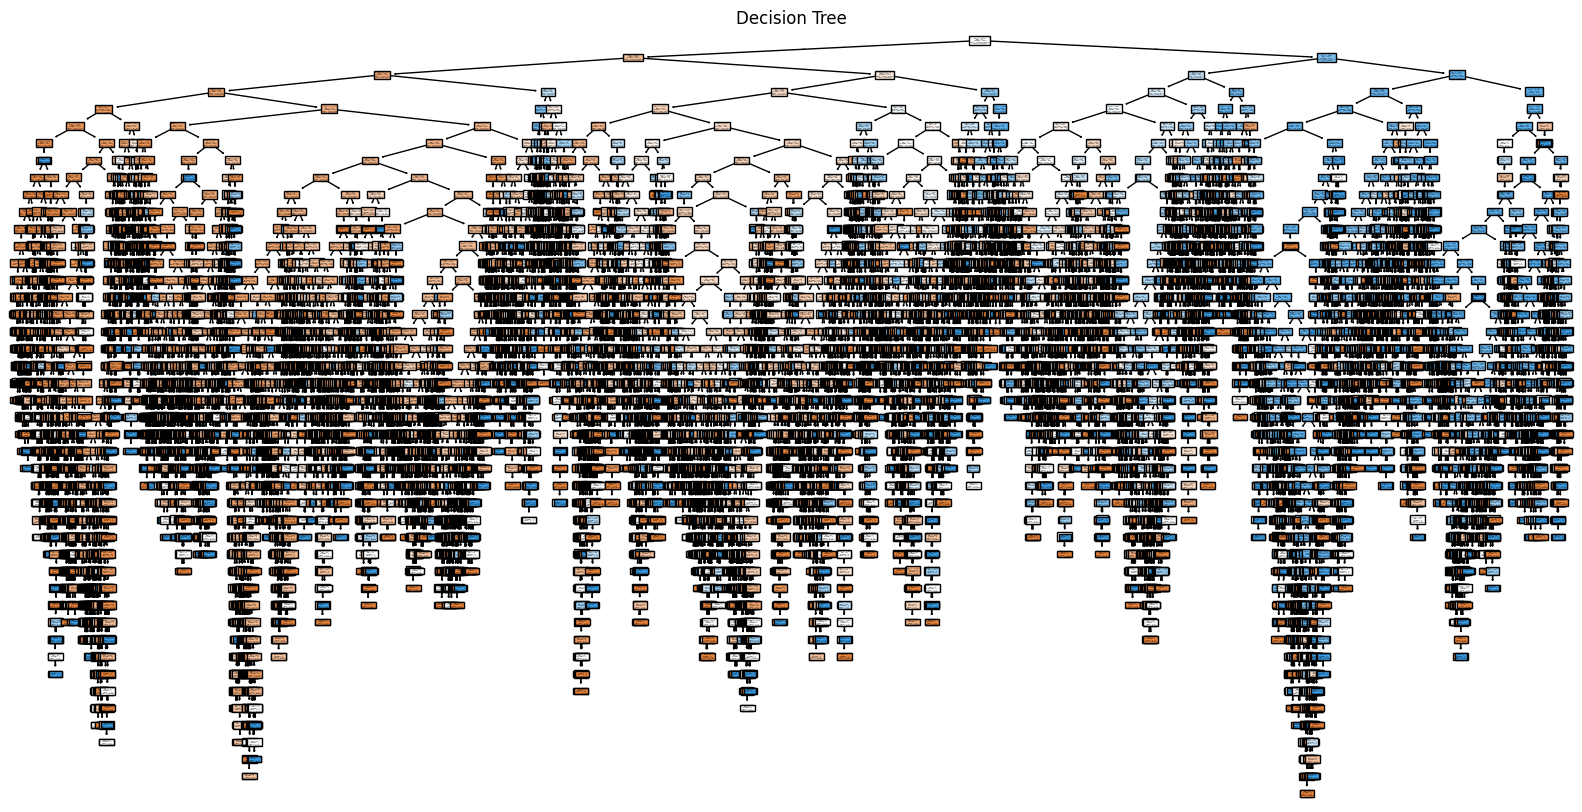

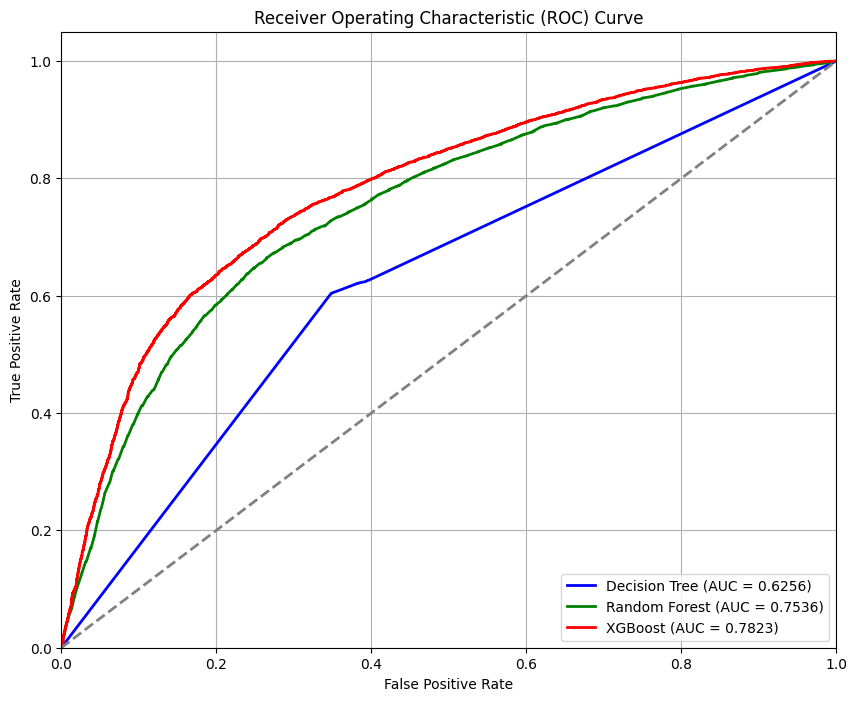

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import joblib

# Load Cleaned Dataset
X = pd.read_csv(r"cardio_clean.csv")
y = pd.read_csv(r"cardio_clean_labels.csv").squeeze("columns")

# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Load Scaler
scaler = joblib.load("scaler.joblib")
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
X_train[numerical_columns] = scaler.transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

# Initialize and Train Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Initialize and Train Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Initialize and Train XGBoost Classifier
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Plot Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True)
plt.title('Decision Tree')
plt.show()

# Plot ROC-AUC for all three models

# Predict probabilities for ROC-AUC
y_pred_dt = dt.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area for each model
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plotting the ROC-AUC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, color='blue', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()
